In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)

print("Библиотеки успешно загружены")

Библиотеки успешно загружены


In [18]:
df = pd.read_csv("../data/car data.csv")

print("Размер датасета:", df.shape)
df.head()

Размер датасета: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [20]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Car_Name,301,98,city,26,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Year,301.0,NaN,NaN,NaN,2013.627907,2.891554,2003.0,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,NaN,NaN,NaN,4.661296,5.082812,0.1,0.9,3.6,6.0,35.0
Present_Price,301.0,NaN,NaN,NaN,7.628472,8.642584,0.32,1.2,6.4,9.9,92.6
Driven_kms,301.0,NaN,NaN,NaN,36947.20598,38886.883882,500.0,15000.0,32000.0,48767.0,500000.0
Fuel_Type,301,3,Petrol,239,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Selling_type,301,2,Dealer,195,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Transmission,301,2,Manual,261,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Owner,301.0,NaN,NaN,NaN,0.043189,0.247915,0.0,0.0,0.0,0.0,3.0


In [21]:
print("Пропущенные значения по столбцам:")
print(df.isna().sum())
print()
print("Количество дубликатов:", df.duplicated().sum())

Пропущенные значения по столбцам:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Количество дубликатов: 2


In [22]:
for col in ["Fuel_Type", "Selling_type", "Transmission", "Owner"]:
    print(f"{col}: {df[col].unique()}")

Fuel_Type: ['Petrol' 'Diesel' 'CNG']
Selling_type: ['Dealer' 'Individual']
Transmission: ['Manual' 'Automatic']
Owner: [0 1 3]


In [23]:
df["Car_Age"] = 2024 - df["Year"]
df.drop(columns=["Year"], inplace=True)

print("Типы данных после преобразования:")
print(df.dtypes)
df.head()

Типы данных после преобразования:
Car_Name          object
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
Car_Age            int64
dtype: object


,Car_Name,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,3.35,5.59,27000,Petrol,Dealer,Manual,0,10
1,sx4,4.75,9.54,43000,Diesel,Dealer,Manual,0,11
2,ciaz,7.25,9.85,6900,Petrol,Dealer,Manual,0,7
3,wagon r,2.85,4.15,5200,Petrol,Dealer,Manual,0,13
4,swift,4.60,6.87,42450,Diesel,Dealer,Manual,0,10


In [24]:
df = df.drop_duplicates().reset_index(drop=True)
print("Размер после удаления дубликатов:", df.shape)

Размер после удаления дубликатов: (299, 9)


In [25]:
print("Driven_kms <= 0:", (df["Driven_kms"] <= 0).sum())
print("Selling_Price <= 0:", (df["Selling_Price"] <= 0).sum())
print("Present_Price <= 0:", (df["Present_Price"] <= 0).sum())
print("Car_Age < 0:", (df["Car_Age"] < 0).sum())

Driven_kms <= 0: 0
Selling_Price <= 0: 0
Present_Price <= 0: 0
Car_Age < 0: 0


In [26]:
Q1, Q3 = df["Selling_Price"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR

outliers = df[(df["Selling_Price"] < lower) | (df["Selling_Price"] > upper)]
print(f"Выбросов в Selling_Price: {len(outliers)} из {len(df)} "
      f"({len(outliers)/len(df):.1%})")

df_clean = df.copy()

Выбросов в Selling_Price: 16 из 299 (5.4%)


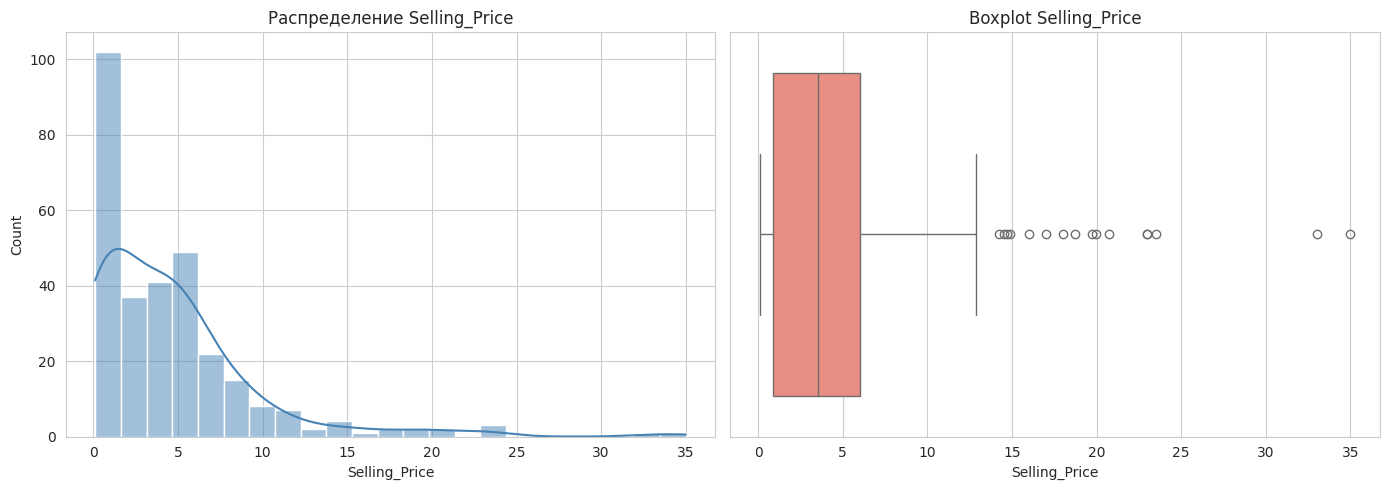

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df_clean["Selling_Price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Распределение Selling_Price")

sns.boxplot(x=df_clean["Selling_Price"], ax=axes[1], color="salmon")
axes[1].set_title("Boxplot Selling_Price")

plt.tight_layout()
plt.savefig("../eda/01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Вывод: есть выборсы в виде дорогих автомобилей

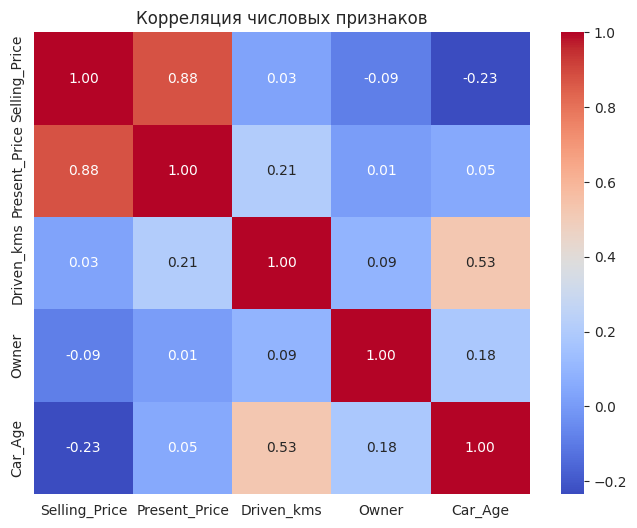

In [36]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(
    df_clean.select_dtypes(include=np.number).corr(),
    annot=True, cmap="coolwarm", fmt=".2f", ax=ax
)
ax.set_title("Корреляция числовых признаков")
plt.savefig("../eda/02_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Вывод: наиболее сильная корреляция у параметров цены покупки и продажи автомобиля, возраст автомобиля имеет отрицательную корреляцию (чем старше автомобиль тем он дешевле)

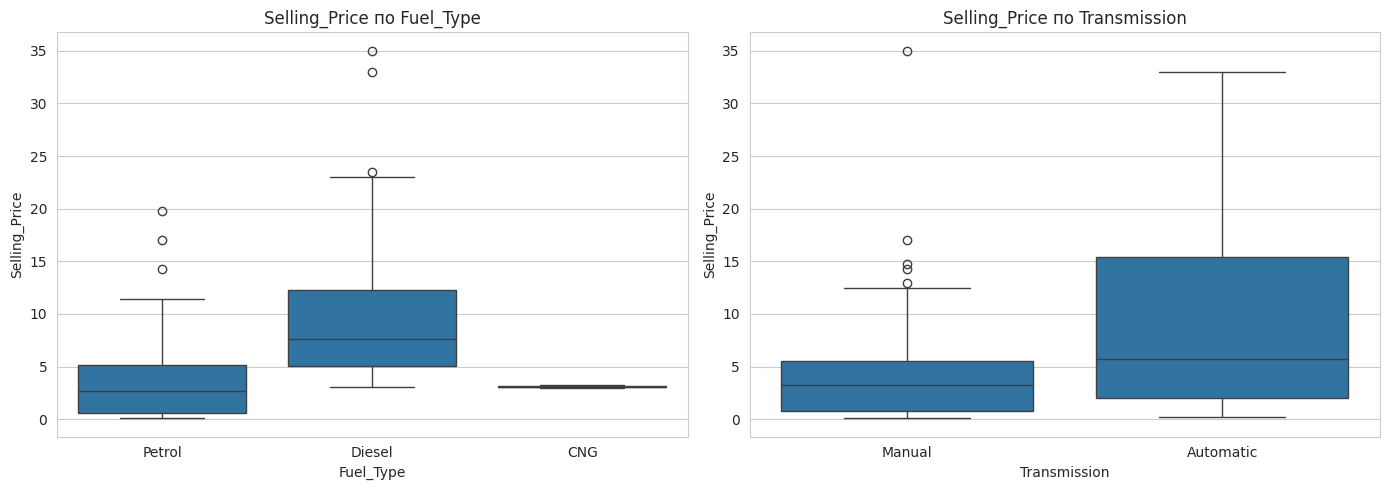

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_clean, x="Fuel_Type", y="Selling_Price", ax=axes[0])
axes[0].set_title("Selling_Price по Fuel_Type")

sns.boxplot(data=df_clean, x="Transmission", y="Selling_Price", ax=axes[1])
axes[1].set_title("Selling_Price по Transmission")

plt.tight_layout()
plt.savefig("../eda/03_price_by_category.png", dpi=150, bbox_inches="tight")
plt.show()

Вывод: дизельные и автоматические автомобили в среднем дороже бензиновых и механических.

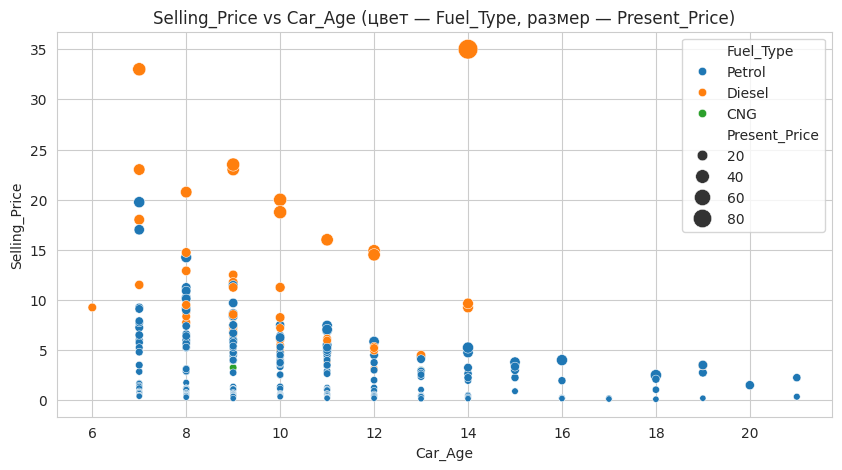

In [38]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.scatterplot(
    data=df_clean, x="Car_Age", y="Selling_Price",
    hue="Fuel_Type", size="Present_Price", sizes=(20, 200), ax=ax
)
ax.set_title("Selling_Price vs Car_Age (цвет — Fuel_Type, размер — Present_Price)")
plt.savefig("../eda/04_price_vs_age.png", dpi=150, bbox_inches="tight")
plt.show()

Вывод: На графика видна зависимость, чем старше автомобиль,тем он дешевле.

In [40]:
fig = px.scatter(
    df_clean,
    x="Present_Price",
    y="Selling_Price",
    color="Fuel_Type",
    size="Driven_kms",
    hover_data=["Car_Name", "Car_Age", "Transmission", "Selling_type"],
    title="Интерактивно: Present_Price vs Selling_Price",
    template="plotly_white"
)
fig.write_html("../eda/05_present_vs_selling_price.html")
fig.show()

In [32]:
df_final = pd.get_dummies(
    df_clean,
    columns=["Fuel_Type", "Selling_type", "Transmission"],
    drop_first=True
)

df_final = df_final.drop(columns=["Car_Name"])

print("Финальный датасет:", df_final.shape)
df_final.head()

Финальный датасет: (299, 9)


,Selling_Price,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Selling_type_Individual,Transmission_Manual
0,3.35,5.59,27000,0,10,False,True,False,True
1,4.75,9.54,43000,0,11,True,False,False,True
2,7.25,9.85,6900,0,7,False,True,False,True
3,2.85,4.15,5200,0,13,False,True,False,True
4,4.60,6.87,42450,0,10,True,False,False,True


In [ ]:
df_final.to_csv("../data/car_data_clean.csv", index=False)
df_final.to_pickle("../data/car_data_clean.pkl")

Финальный датасет: (299, 9)
Сохранено: ../data/car_data_clean.csv и ../data/car_data_clean.pkl
